# 05. Inference, Intervals, and Prediction

Regression output gives a fitted line, but decisions usually need uncertainty. This chapter covers slope tests, coefficient confidence intervals, mean-response confidence intervals, and prediction intervals.

This chapter separates two interval types:

- confidence interval for the mean response at a given predictor value,
- prediction interval for a new individual observation at that predictor value.

Prediction intervals are wider because individual observations vary around the mean.

## Fit the model again

## Browser package setup

Run the next cell before the first analysis cell. It loads the scientific Python packages used in this module into the browser-based Python kernel.

The first run in a browser session can take a little time. Later notebooks usually load faster because the browser can reuse cached packages.


In [1]:
from lite_setup import ensure_packages
await ensure_packages()


Using the current Python environment.


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm

from checks import check, check_close, check_interval_order

fuel = pd.read_csv("data/fuelcons.csv")
model = ols("Fuelcons ~ Temp", data=fuel).fit()

## Testing whether the slope is useful

The first regression hypothesis test usually asks whether the slope is zero:

$$
H_0: \beta_1 = 0
$$

against

$$
H_a: \beta_1 \neq 0.
$$

If $\beta_1=0$, the mean response does not change linearly with the predictor. If we reject $H_0$, we have evidence that the predictor is linearly related to the response.

## Coefficient inference formulas

Software gives the coefficient table automatically, but the formulas are useful for checking what the output means. Let

$$
S_{xx} = \sum_{i=1}^{n}(x_i-\bar{x})^2, \qquad
s = \sqrt{\frac{SSE}{n-2}}.
$$

For simple linear regression with an intercept,

$$
SE(b_1)=\frac{s}{\sqrt{S_{xx}}}, \qquad
SE(b_0)=s\sqrt{\frac{1}{n}+\frac{\bar{x}^2}{S_{xx}}}.
$$

A two-sided confidence interval for a coefficient has the form

$$
b_j \pm t_{\alpha/2,n-2}SE(b_j).
$$

The slope interval is usually the most important one for interpretation. The intercept interval is also valid mathematically, but it should be interpreted carefully when $x=0$ is outside the observed range or has no practical meaning.


In [3]:
slope_estimate = model.params["Temp"]
slope_se = model.bse["Temp"]
slope_t = model.tvalues["Temp"]
slope_p = model.pvalues["Temp"]
slope_ci = model.conf_int().loc["Temp"]

print(f"slope estimate = {slope_estimate:.4f}")
print(f"slope standard error = {slope_se:.4f}")
print(f"t statistic = {slope_t:.3f}")
print(f"p-value = {slope_p:.6f}")
print(f"95% CI for slope = ({slope_ci[0]:.4f}, {slope_ci[1]:.4f})")

slope estimate = -0.1279
slope standard error = 0.0175
t statistic = -7.328
p-value = 0.000330
95% CI for slope = (-0.1706, -0.0852)


In [4]:
alpha = 0.05
print(check(
    slope_p < alpha,
    "The slope p-value is below 0.05, so the fitted linear relationship is statistically significant at the 5% level.",
    "The p-value is not below 0.05. Recheck that you are reading the Temp row, not the Intercept row."
))
print(check_close("slope p-value", slope_p, expected=0.00033, tolerance=0.00005))

PASS: The slope p-value is below 0.05, so the fitted linear relationship is statistically significant at the 5% level.
PASS: slope p-value is close enough: 0.0003301.


Interpretation: we estimate that each one-unit increase in temperature is associated with a decrease in mean weekly fuel consumption between about 0.085 and 0.171 units, using a 95% confidence interval for the slope.

## ANOVA table and F-test

For simple linear regression, the F-test for the regression model answers the same significance question as the two-sided slope t-test.

The total variation in the response is split into:

$$
SST = SSR + SSE,
$$

where:

- $SST$ is total variation around $\bar y$,
- $SSR$ is variation explained by the regression,
- $SSE$ is unexplained residual variation.

In [5]:
anova_table = anova_lm(model)
anova_table

,df,sum_sq,mean_sq,F,PR(>F)
Temp,1.0,22.980816,22.980816,53.694882,0.00033
Residual,6.0,2.567934,0.427989,NaN,NaN


In [6]:
f_stat = anova_table.loc["Temp", "F"]
f_p = anova_table.loc["Temp", "PR(>F)"]

print(f"F statistic = {f_stat:.3f}")
print(f"F-test p-value = {f_p:.6f}")
print(check_close("F statistic", f_stat, expected=53.695, tolerance=0.02))

F statistic = 53.695
F-test p-value = 0.000330
PASS: F statistic is close enough: 53.69.


## Get intervals for the observed data

`summary_frame()` returns the fitted mean, the confidence interval for the mean, and the prediction interval for individual observations.

In [7]:
pred = model.get_prediction(fuel[["Temp"]])
intervals = pred.summary_frame(alpha=0.05)
intervals

,mean,mean_se,mean_ci_lower,mean_ci_upper,obs_ci_lower,obs_ci_upper
0,12.256049,0.362316,11.369493,13.142606,10.426155,14.085944
1,12.256049,0.362316,11.369493,13.142606,10.426155,14.085944
2,11.680402,0.305987,10.931679,12.429124,9.913167,13.447636
3,10.848911,0.247066,10.244362,11.453459,9.137768,12.560054
4,9.966251,0.233726,9.394343,10.538158,8.266366,11.666136
5,8.443982,0.334286,7.626013,9.261951,6.646316,10.241649
6,8.405606,0.338087,7.578337,9.232874,6.603689,10.207523
7,7.842750,0.397598,6.869863,8.815638,5.969507,9.715994


Important columns:

- `mean`: fitted mean response
- `mean_ci_lower`, `mean_ci_upper`: confidence interval for the mean response
- `obs_ci_lower`, `obs_ci_upper`: prediction interval for a new observation

## Predict at one new temperature

## Manual formulas for mean and prediction intervals

For a new predictor value $x_0$, the fitted mean is

$$
\hat{y}_0=b_0+b_1x_0.
$$

The confidence interval for the mean response at $x_0$ is

$$
\hat{y}_0 \pm t_{\alpha/2,n-2}\,s
\sqrt{\frac{1}{n}+\frac{(x_0-\bar{x})^2}{S_{xx}}}.
$$

The prediction interval for one new individual observation at $x_0$ is

$$
\hat{y}_0 \pm t_{\alpha/2,n-2}\,s
\sqrt{1+\frac{1}{n}+\frac{(x_0-\bar{x})^2}{S_{xx}}}.
$$

The extra `1` inside the prediction interval square root is the new observation's own random error. That is why prediction intervals are always wider than mean-response confidence intervals at the same $x_0$ and confidence level.


In [8]:
new_temp = 40
new_data = pd.DataFrame({"Temp": [new_temp]})
prediction_40 = model.get_prediction(new_data).summary_frame(alpha=0.05)
prediction_40

,mean,mean_se,mean_ci_lower,mean_ci_upper,obs_ci_lower,obs_ci_upper
0,10.720989,0.241483,10.130101,11.311876,9.014624,12.427353


In [9]:
mean_40 = prediction_40.loc[0, "mean"]
mean_ci_lower = prediction_40.loc[0, "mean_ci_lower"]
mean_ci_upper = prediction_40.loc[0, "mean_ci_upper"]
obs_ci_lower = prediction_40.loc[0, "obs_ci_lower"]
obs_ci_upper = prediction_40.loc[0, "obs_ci_upper"]

print(check_close("predicted mean at Temp = 40", mean_40, expected=10.721, tolerance=0.02))
print(check_interval_order(mean_ci_lower, mean_40, mean_ci_upper, "confidence interval"))
print(check_interval_order(obs_ci_lower, mean_40, obs_ci_upper, "prediction interval"))

PASS: predicted mean at Temp = 40 is close enough: 10.72.
PASS: confidence interval is ordered correctly: lower < estimate < upper.
PASS: prediction interval is ordered correctly: lower < estimate < upper.


## Checkpoint: which interval is wider?

In [10]:
mean_ci_width = mean_ci_upper - mean_ci_lower
prediction_interval_width = obs_ci_upper - obs_ci_lower

print(f"Mean confidence interval width: {mean_ci_width:.3f}")
print(f"Prediction interval width: {prediction_interval_width:.3f}")

print(check(
    prediction_interval_width > mean_ci_width,
    "Correct. The prediction interval is wider because it includes individual-observation noise.",
    "Recheck the columns. The prediction interval should use obs_ci_lower and obs_ci_upper."
))

Mean confidence interval width: 1.182
Prediction interval width: 3.413
PASS: Correct. The prediction interval is wider because it includes individual-observation noise.


## Compare several temperatures

Change the values in `temps_to_predict` and rerun the cell.

In [11]:
temps_to_predict = [30, 40, 50, 60]
new_points = pd.DataFrame({"Temp": temps_to_predict})

comparison = model.get_prediction(new_points).summary_frame(alpha=0.05)
comparison.insert(0, "Temp", temps_to_predict)
comparison

,Temp,mean,mean_se,mean_ci_lower,mean_ci_upper,obs_ci_lower,obs_ci_upper
0,30,12.000206,0.336182,11.177599,12.822813,10.200424,13.799988
1,40,10.720989,0.241483,10.130101,11.311876,9.014624,12.427353
2,50,9.441772,0.254090,8.820037,10.063507,7.724481,11.159062
3,60,8.162555,0.362989,7.274353,9.050756,6.331863,9.993246


## Visualize uncertainty

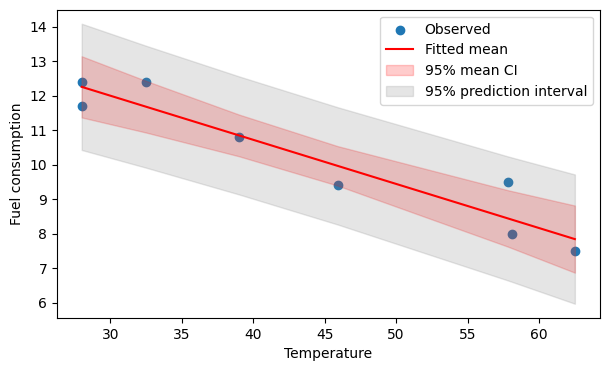

In [12]:
plot_grid = pd.DataFrame({"Temp": sorted(fuel["Temp"].tolist())})
plot_intervals = model.get_prediction(plot_grid).summary_frame(alpha=0.05)

fig, ax = plt.subplots(figsize=(7, 4))
ax.scatter(fuel["Temp"], fuel["Fuelcons"], label="Observed")
ax.plot(plot_grid["Temp"], plot_intervals["mean"], color="red", label="Fitted mean")
ax.fill_between(
    plot_grid["Temp"],
    plot_intervals["mean_ci_lower"],
    plot_intervals["mean_ci_upper"],
    color="red",
    alpha=0.2,
    label="95% mean CI",
)
ax.fill_between(
    plot_grid["Temp"],
    plot_intervals["obs_ci_lower"],
    plot_intervals["obs_ci_upper"],
    color="gray",
    alpha=0.2,
    label="95% prediction interval",
)
ax.set_xlabel("Temperature")
ax.set_ylabel("Fuel consumption")
ax.legend()
plt.show()

## Confidence level

The `alpha` argument is the probability left outside the interval.

- `alpha=0.05` gives a 95% interval.
- `alpha=0.10` gives a 90% interval.
- `alpha=0.01` gives a 99% interval.

In [13]:
prediction_40_90 = model.get_prediction(new_data).summary_frame(alpha=0.10)
prediction_40_99 = model.get_prediction(new_data).summary_frame(alpha=0.01)

width_90 = prediction_40_90.loc[0, "obs_ci_upper"] - prediction_40_90.loc[0, "obs_ci_lower"]
width_99 = prediction_40_99.loc[0, "obs_ci_upper"] - prediction_40_99.loc[0, "obs_ci_lower"]

print(f"90% prediction interval width: {width_90:.3f}")
print(f"99% prediction interval width: {width_99:.3f}")
print(check(width_99 > width_90, "Correct. Higher confidence requires a wider interval.", "Recheck alpha: 99% uses alpha=0.01."))

90% prediction interval width: 2.710
99% prediction interval width: 5.171
PASS: Correct. Higher confidence requires a wider interval.


## What to remember

Use a coefficient confidence interval when the question is about an unknown parameter such as the slope. Use a mean-response confidence interval when the question is about the average response at a chosen predictor value. Use a prediction interval when the question is about a new individual outcome. For practical forecasting, prediction intervals are often the more honest answer.